# 0. Environment preparation
## 0.1. Importing libraries

In [61]:
# ok so we need all these libraries to make everything work
# pandas and numpy are basically just for handling the data
# matplotlib is for making the graphs look nice at the end
# sklearn has all the actual ML stuff we need like the models and tuning tools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns  # for cleaner, more detailed plots alongside matplotlib

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, TargetEncoder, FunctionTransformer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.compose import ColumnTransformer

import warnings
warnings.filterwarnings("ignore")  # just hiding annoying warnings that dont really matter

## 0.2. Loading the dataset

In [62]:
df = pd.read_csv("uae_real_estate_2024.csv")

# 1. Initial Dataset Analysis
## 1.1. Basic overview

In [63]:
print("Shape:", df.shape)

Shape: (5058, 12)


In [64]:
df.describe(include='all')

,title,displayAddress,bathrooms,bedrooms,addedOn,type,price,verified,priceDuration,sizeMin,furnishing,description
count,5058,5058,4938,4935,5058,5058,5.058000e+03,5058,5058,5058,5056,5057
unique,5002,1886,9,9,4927,1,NaN,2,1,2516,3,4940
top,Waterfront | Emaar | Luxury | PP 80/20,"Hayyan, Sharjah",2,1,2024-07-29T14:12:37Z,Residential for Sale,NaN,True,sell,3014 sqft,NO,*Luxury residential complex with a 5% down pay...
freq,3,40,1209,1265,7,5058,NaN,3271,5058,46,3630,8
mean,NaN,NaN,NaN,NaN,NaN,NaN,5.050924e+06,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,1.000928e+07,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e+05,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,1.200000e+06,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,2.350000e+06,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,4.499375e+06,NaN,NaN,NaN,NaN,NaN


In [65]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5058 entries, 0 to 5057
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   title           5058 non-null   str  
 1   displayAddress  5058 non-null   str  
 2   bathrooms       4938 non-null   str  
 3   bedrooms        4935 non-null   str  
 4   addedOn         5058 non-null   str  
 5   type            5058 non-null   str  
 6   price           5058 non-null   int64
 7   verified        5058 non-null   bool 
 8   priceDuration   5058 non-null   str  
 9   sizeMin         5058 non-null   str  
 10  furnishing      5056 non-null   str  
 11  description     5057 non-null   str  
dtypes: bool(1), int64(1), str(10)
memory usage: 439.7 KB


In [66]:
print("\nFirst 3 rows:")
df.head(3)


First 3 rows:


,title,displayAddress,bathrooms,bedrooms,addedOn,type,price,verified,priceDuration,sizeMin,furnishing,description
0,Great ROI I High Floor I Creek View,"Binghatti Canal, Business Bay, Dubai",3,2,2024-08-14T12:02:53Z,Residential for Sale,2500000,True,sell,1323 sqft,NO,MNA Properties is delighted to offer this apar...
1,Full Sea View | Beach Life | Brand New Residence,"La Vie, Jumeirah Beach Residence, Dubai",3,2,2024-08-13T05:45:16Z,Residential for Sale,7200000,True,sell,1410 sqft,YES,"Apartment for sale in La Vie, Jumeirah Beach R..."
2,Green Belt | Corner Unit | Spacious Plot,"La Rosa 6, Villanova, Dubai Land, Dubai",3,4,2024-08-14T06:24:28Z,Residential for Sale,3600000,True,sell,2324 sqft,NO,Treo Homes is very pleased to be bringing to t...


In [67]:
print("Shape: ", df.shape)

Shape:  (5058, 12)


In [68]:
print("\nUnique values per column:\n")
print(df.nunique())


Unique values per column:

title             5002
displayAddress    1886
bathrooms            9
bedrooms             9
addedOn           4927
type                 1
price             1542
verified             2
priceDuration        1
sizeMin           2516
furnishing           3
description       4940
dtype: int64


## 1.2. Checking for Missing Values

In [69]:
print("=== Missing Values ===")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

=== Missing Values ===
title               0
displayAddress      0
bathrooms         120
bedrooms          123
addedOn             0
type                0
price               0
verified            0
priceDuration       0
sizeMin             0
furnishing          2
description         1
dtype: int64

Total missing: 246


## 1.3. Checking for Duplicates

In [70]:
print("\n==== Duplicate Rows ====")
print(f"Number of duplicates: {df.duplicated().sum()}")


==== Duplicate Rows ====
Number of duplicates: 0


# 2. Preprocesing
## 2.1. Preprocessing on the Whole Dataset
### 2.1.1. Dropping Useless Columns

In [71]:
# Drop columns with only 1 unique value - no predictive power
# 'type' is always "Residential for Sale", 'priceDuration' is always "sell"
df = df.drop(columns=['type', 'priceDuration'])
print("Dropped 'type' and 'priceDuration' (constant columns)")

# Drop 'title' and 'description' - free text, not useful for prediction in our case, and would require complex NLP to extract value
df = df.drop(columns=['title', 'description'])
print("Dropped 'title' and 'description' (unstructured text)")

Dropped 'type' and 'priceDuration' (constant columns)
Dropped 'title' and 'description' (unstructured text)


In [72]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5058 entries, 0 to 5057
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   displayAddress  5058 non-null   str  
 1   bathrooms       4938 non-null   str  
 2   bedrooms        4935 non-null   str  
 3   addedOn         5058 non-null   str  
 4   price           5058 non-null   int64
 5   verified        5058 non-null   bool 
 6   sizeMin         5058 non-null   str  
 7   furnishing      5056 non-null   str  
dtypes: bool(1), int64(1), str(6)
memory usage: 281.7 KB


### 2.1.2. Fixing Data Types

In [73]:
# Fix 'sizeMin': remove " sqft" and convert to numeric
df['sizeMin'] = df['sizeMin'].str.replace(' sqft', '', regex=False)
df['sizeMin'] = pd.to_numeric(df['sizeMin'], errors='coerce')
print("\n'sizeMin' converted to numeric")

# Fix 'addedOn': parse datetime and extract month (seasonality signal)
df['addedOn'] = pd.to_datetime(df['addedOn'], utc=True)
df['month_listed'] = df['addedOn'].dt.month
df = df.drop(columns=['addedOn'])
print("'addedOn' parsed - extracted 'month_listed', original column dropped")

# Fix 'bathrooms' and 'bedrooms': they loaded as object, convert to numeric
# Both loaded as objects because of values like "7+" and "studio"
df['bathrooms'] = df['bathrooms'].replace({'7+': 7})
df['bathrooms'] = pd.to_numeric(df['bathrooms'], errors='coerce')

df['bedrooms'] = df['bedrooms'].replace({'studio': 0, '7+': 7})
df['bedrooms'] = pd.to_numeric(df['bedrooms'], errors='coerce')
print("'bathrooms' and 'bedrooms' converted to numeric")

print("\n=== Updated dtypes ===")
print(df.dtypes)
print("\nShape:", df.shape)


'sizeMin' converted to numeric
'addedOn' parsed - extracted 'month_listed', original column dropped
'bathrooms' and 'bedrooms' converted to numeric

=== Updated dtypes ===
displayAddress        str
bathrooms         float64
bedrooms          float64
price               int64
verified             bool
sizeMin             int64
furnishing            str
month_listed        int32
dtype: object

Shape: (5058, 8)


### 2.1.3. Droping Rows with Missing Values

In [74]:
# Furnishing
# Since furnishing has a significant impact on price and there are only two missing values, dropping them is a better approach than imputing, which could introduce bias).

print("\n=== Shape Before ===")
print(df.shape)

mask = df.query('furnishing.isnull()')
df.drop(index = mask.index, inplace=True)

print("\n=== Shape After ===")
print(df.shape)


=== Shape Before ===
(5058, 8)

=== Shape After ===
(5056, 8)


### 2.1.4. One-Hot Encoding Variables

In [75]:
# Furnishing
# One-Hot encode (NO / YES / PARTLY)
# drop_first=False so all 3 categories are visible and explainable

print("\n=== Info Before ===")
print(df.info())

df = pd.get_dummies(df, columns=['furnishing'], drop_first=False, sparse=False, prefix='furnished', dtype=int)


=== Info Before ===
<class 'pandas.DataFrame'>
Index: 5056 entries, 0 to 5057
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   displayAddress  5056 non-null   str    
 1   bathrooms       4935 non-null   float64
 2   bedrooms        4933 non-null   float64
 3   price           5056 non-null   int64  
 4   verified        5056 non-null   bool   
 5   sizeMin         5056 non-null   int64  
 6   furnishing      5056 non-null   str    
 7   month_listed    5056 non-null   int32  
dtypes: bool(1), float64(2), int32(1), int64(2), str(2)
memory usage: 301.2 KB
None


In [76]:
print("\n=== Info After ===")
print(df.info())


=== Info After ===
<class 'pandas.DataFrame'>
Index: 5056 entries, 0 to 5057
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   displayAddress    5056 non-null   str    
 1   bathrooms         4935 non-null   float64
 2   bedrooms          4933 non-null   float64
 3   price             5056 non-null   int64  
 4   verified          5056 non-null   bool   
 5   sizeMin           5056 non-null   int64  
 6   month_listed      5056 non-null   int32  
 7   furnished_NO      5056 non-null   int64  
 8   furnished_PARTLY  5056 non-null   int64  
 9   furnished_YES     5056 non-null   int64  
dtypes: bool(1), float64(2), int32(1), int64(5), str(1)
memory usage: 380.2 KB
None


### 2.1.5. Encoding Categorical Variables

In [77]:
# Verified
# Convert bool to int (True=1, False=0)

print("\n=== Data Frame Before ===")
print(df.head(3))

df['verified'] = df['verified'].map({True: 1, False: 0})

print("\n=== Data Frame After ===")
df.head(3)


=== Data Frame Before ===
                            displayAddress  bathrooms  bedrooms    price  \
0     Binghatti Canal, Business Bay, Dubai        3.0       2.0  2500000   
1  La Vie, Jumeirah Beach Residence, Dubai        3.0       2.0  7200000   
2  La Rosa 6, Villanova, Dubai Land, Dubai        3.0       4.0  3600000   

   verified  sizeMin  month_listed  furnished_NO  furnished_PARTLY  \
0      True     1323             8             1                 0   
1      True     1410             8             0                 0   
2      True     2324             8             1                 0   

   furnished_YES  
0              0  
1              1  
2              0  

=== Data Frame After ===


,displayAddress,bathrooms,bedrooms,price,verified,sizeMin,month_listed,furnished_NO,furnished_PARTLY,furnished_YES
0,"Binghatti Canal, Business Bay, Dubai",3.0,2.0,2500000,1,1323,8,1,0,0
1,"La Vie, Jumeirah Beach Residence, Dubai",3.0,2.0,7200000,1,1410,8,0,0,1
2,"La Rosa 6, Villanova, Dubai Land, Dubai",3.0,4.0,3600000,1,2324,8,1,0,0


### 2.1.6. Outlier Detection & Removal


Shape before outlier handling: (5056, 10)


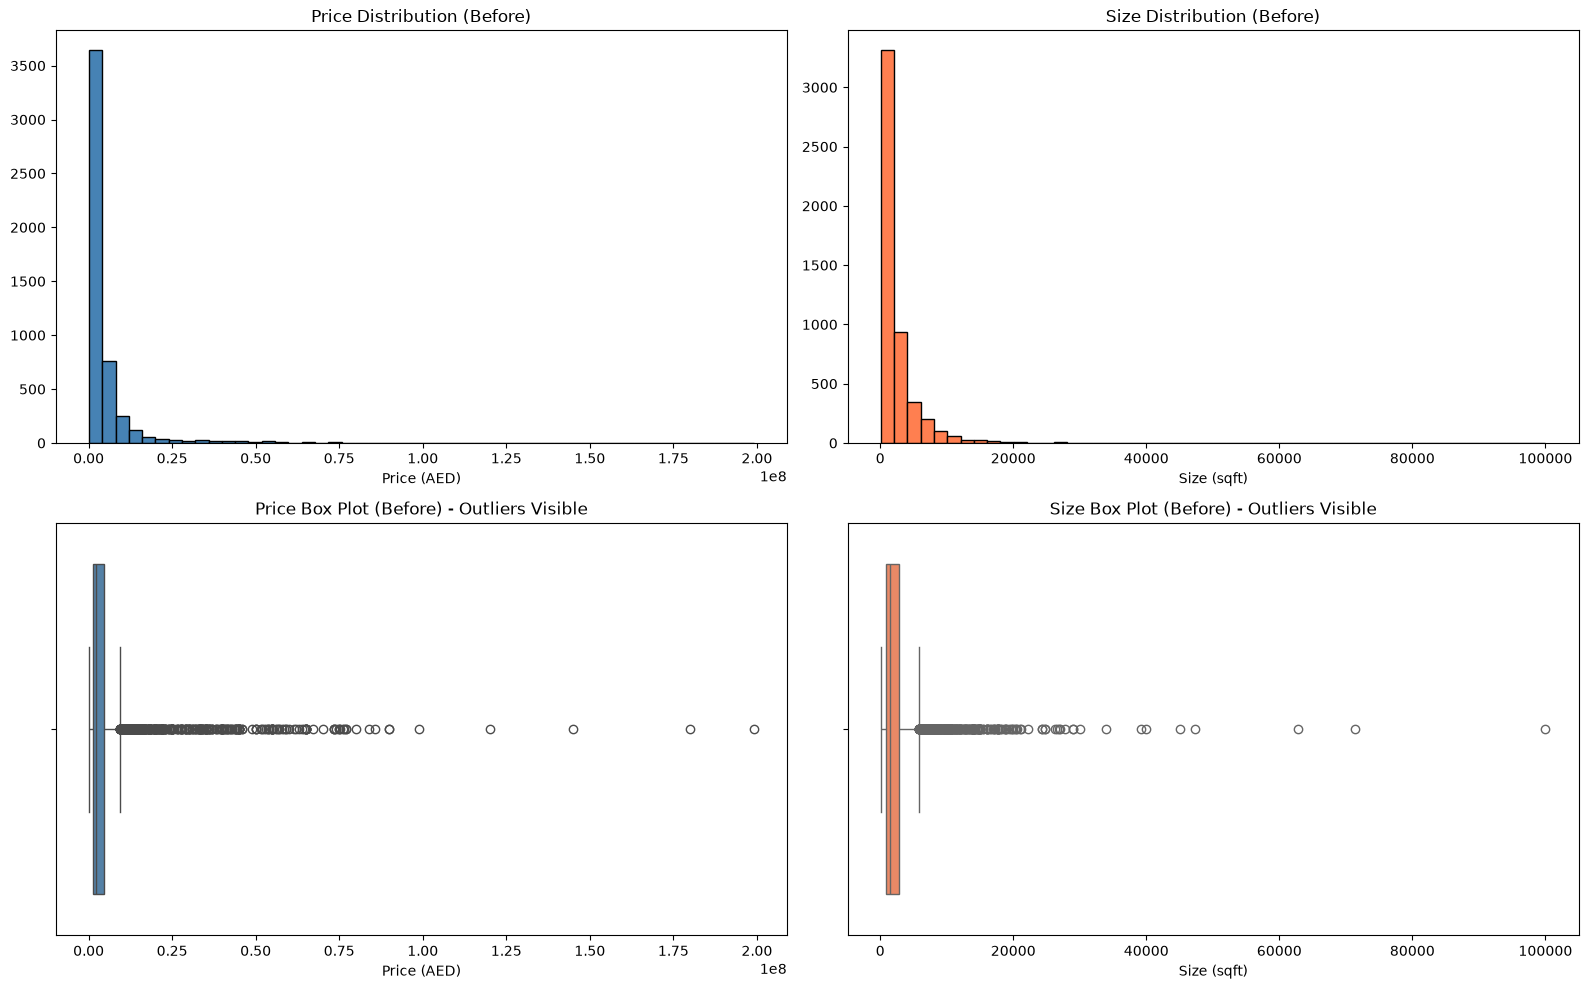

Total rows removed: 1641 (from 5056 to 3415)


Shape after outlier handling: (3415, 10)


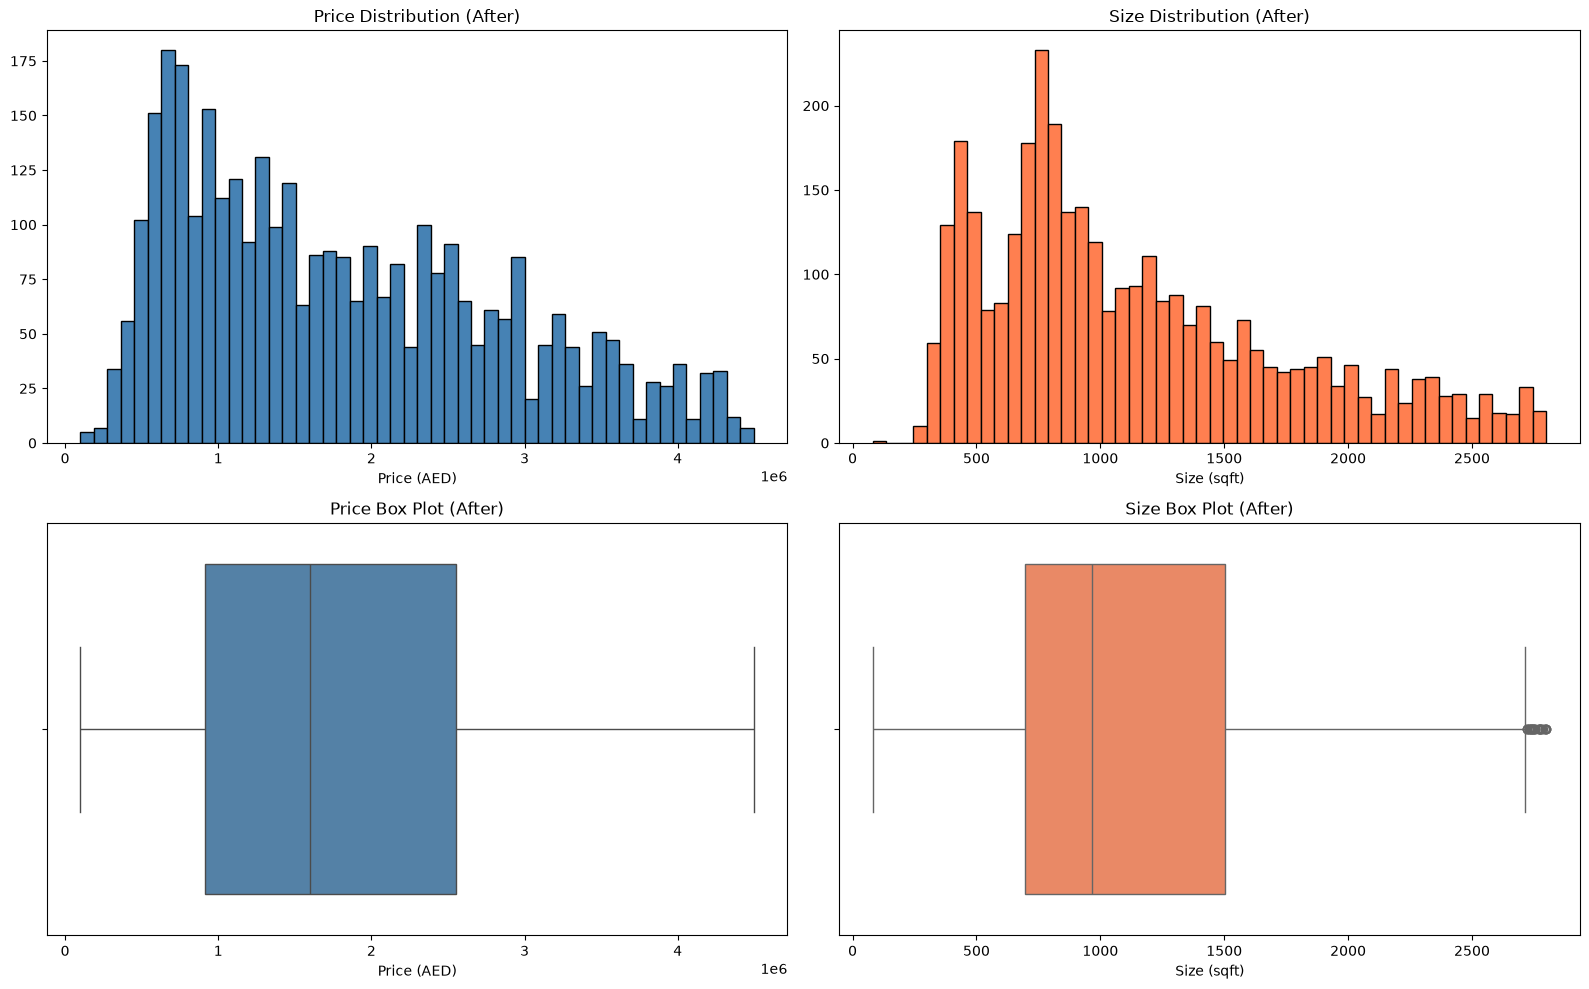

In [ ]:
print(f"\nShape before outlier handling: {df.shape}")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Histograms BEFORE outlier handling
axes[0, 0].hist(df['price'], bins=50, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Price Distribution (Before)')
axes[0, 0].set_xlabel('Price (AED)')

axes[0, 1].hist(df['sizeMin'], bins=50, color='coral', edgecolor='black')
axes[0, 1].set_title('Size Distribution (Before)')
axes[0, 1].set_xlabel('Size (sqft)')

# Box Plots BEFORE outlier handling
sns.boxplot(x=df['price'], ax=axes[1, 0], color='steelblue')
axes[1, 0].set_title('Price Box Plot (Before) - Outliers Visible')
axes[1, 0].set_xlabel('Price (AED)')

sns.boxplot(x=df['sizeMin'], ax=axes[1, 1], color='coral')
axes[1, 1].set_title('Size Box Plot (Before) - Outliers Visible')
axes[1, 1].set_xlabel('Size (sqft)')

plt.tight_layout()
plt.show()

# Outlier handling function

def handle_top_outliers(dataframe, columns):
    #Handles only the top extreme outliers.

    percentile=90

    upper_limits = dataframe[columns].quantile(percentile / 100.0)
    before = len(dataframe)
    
    for i in range(len(columns)):
        dataframe = dataframe[dataframe[columns[i]] <= upper_limits[columns[i]]].copy()
        
    removed = before - len(dataframe)
    print(f"Total rows removed: {removed} (from {before} to {len(dataframe)})\n")    
    return dataframe

# Applying top outlier handling
df = handle_top_outliers(df, columns=['price', 'sizeMin'])

print(f"\nShape after outlier handling: {df.shape}")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Histograms AFTER outlier handling
axes[0, 0].hist(df['price'], bins=50, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Price Distribution (After)')
axes[0, 0].set_xlabel('Price (AED)')

axes[0, 1].hist(df['sizeMin'], bins=50, color='coral', edgecolor='black')
axes[0, 1].set_title('Size Distribution (After)')
axes[0, 1].set_xlabel('Size (sqft)')

# Box Plots AFTER outlier handling
sns.boxplot(x=df['price'], ax=axes[1, 0], color='steelblue')
axes[1, 0].set_title('Price Box Plot (After)')
axes[1, 0].set_xlabel('Price (AED)')

sns.boxplot(x=df['sizeMin'], ax=axes[1, 1], color='coral')
axes[1, 1].set_title('Size Box Plot (After)')
axes[1, 1].set_xlabel('Size (sqft)')

plt.tight_layout()
plt.show()

## 2.2. Splitting into training and testing datasets

In [79]:
target_column = 'price'

X = df.drop(columns=[target_column])
y = np.log1p(df[target_column])

# Stratified split to keep price distribution similar in train/test
y_bins = pd.qcut(df[target_column], q=10, duplicates='drop')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y_bins
)

print(f"Train shape: {X_train.shape} | Test shape: {X_test.shape}")

Train shape: (2732, 9) | Test shape: (683, 9)


## 2.3. Preprocessing on Train and Test Set Separately (Risk of Data Leakage)
### 2.3.1. Full Preprocessing Pipeline

In [80]:
# Defining column groups
numeric_features1 = ['bedrooms', 'bathrooms', 'month_listed']
numeric_features2 = ['sizeMin']
categorical_features = ['city']                    # will be extracted from displayAddress
passthrough_features = ['verified', 'furnished_NO', 'furnished_PARTLY', 'furnished_YES']

# Custom function to extract the city
def extract_city(X):
    return X['displayAddress'].str.split(',', n=1).str[1].str.strip().to_frame()

# Preprocessing pipeline
preprocessor = ColumnTransformer([
    # Numerical features 1: impute -> scale
        ('num1', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_features1),
    
    # Numerical features 2: log -> scale
        ('num2', Pipeline([
        ('log', FunctionTransformer(np.log1p, validate=False)),
        ('scaler', StandardScaler())
    ]), numeric_features2),

    # Area, City -> Target Encoding
    ('city', Pipeline([
        ('extract', FunctionTransformer(extract_city)),
        ('encoder', TargetEncoder(target_type='continuous', random_state=42)),
    ]), ['displayAddress']),
    
    # Already encoded binary/categorical features
    ('passthrough', 'passthrough', passthrough_features)
])

print("Full preprocessing pipeline created successfully!")

Full preprocessing pipeline created successfully!


# 3. Model Training
## 3.1. K-Fold Cross Validation (Baseline)

In [81]:
# using 5-fold cross validation - basically splits X_train into 5 chunks
# trains on 4 chunks, tests on 1, repeats 5 times so every chunk gets tested once
# this gives a much more reliable score than just a single train/test split
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# these are the 3 models we're comparing - all using default settings for now (baseline)
# we tune them properly in the next section

models = {
    "Ridge Regression": Pipeline([
        ('preprocessor', preprocessor),
        ('model', Ridge())
    ]),
    "Random Forest": Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(random_state=42))
    ]),
    "HistGradientBoosting": Pipeline([
        ('preprocessor', preprocessor),
        ('model', HistGradientBoostingRegressor(random_state=42))
    ])
}

print("=== Running K-Fold Cross Validation on X_train (Baseline) ===")

cv_results = {}
best_cv_score = float('-inf')
best_model_name = ""

for name, model in models.items():
    # r2 score tells us how well the model explains the variation in price
    # 1.0 = perfect, 0 = no better than just guessing the average price

    scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='r2', n_jobs=-1)

    mean_score = np.mean(scores)
    cv_results[name] = mean_score
    
    print(f"  {name:25} -> Average R2 Score (std dev): {mean_score:.4f}  (±{np.std(scores):.4f})")

    # keeping track of which model did best so far
    if mean_score > best_cv_score:
        best_cv_score = mean_score
        best_model_name = name

print(f"\n Best Baseline Model: {best_model_name} (R2 = {best_cv_score:.4f})\n")

=== Running K-Fold Cross Validation on X_train (Baseline) ===
  Ridge Regression          -> Average R2 Score (std dev): 0.7640  (±0.0168)


  Random Forest             -> Average R2 Score (std dev): 0.8028  (±0.0282)
  HistGradientBoosting      -> Average R2 Score (std dev): 0.7963  (±0.0246)

 Best Baseline Model: Random Forest (R2 = 0.8028)



## 3.2. Hyperparameter Tuning with GridSearchCV

In [82]:
# ok so this is the main part - hyperparameter tuning
# basically we try out a bunch of different settings for each model
# GridSearchCV tests every possible combination and picks the best one
# n_jobs=-1 just means use all CPU cores so it runs faster
print("=== Hyperparameter Tuning ===\n")

# We now use the shared 'preprocessor' from section 2.3 for all models.
# This ensures consistent, leakage-free preprocessing.

# --- Ridge Regression ---
# alpha controls how much we penalize the model for being too complex
# too low = model overfits (memorizes training data), too high = underfits (too simple)
# so we try a wide range to find the sweet spot
ridge_param_dist = {
    'model__alpha': np.logspace(-3, 3, 20),           # Wide range for regularization
    'preprocessor__num1__imputer__strategy': ['mean', 'median']
}

ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

ridge_random = RandomizedSearchCV(
    ridge_pipeline,
    param_distributions=ridge_param_dist,
    n_iter=100,                      # Number of random combinations to try
    cv=kf,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

ridge_random.fit(X_train, y_train)
print(f"Ridge Best Params : {ridge_random.best_params_}  |  R2 = {ridge_random.best_score_:.4f}\n")

# --- Random Forest ---
# n_estimators = how many trees to build (more = better but slower)
# max_depth = how deep each tree can go (too deep = overfitting)
# min_samples_split = minimum rows needed before splitting a node
rf_param_dist = {
    'model__n_estimators': [100, 200, 300, 400, 500],
    'model__max_depth': [None, 10, 15, 20, 25],
    'model__min_samples_split': [2, 5, 10, 15],
    'model__min_samples_leaf': [1, 2, 4, 8],
    'model__max_features': ['sqrt', 'log2', None]
}

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

rf_random = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=100,
    cv=kf,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

rf_random.fit(X_train, y_train)
print(f"Random Forest Best Params : {rf_random.best_params_}  |  R2 = {rf_random.best_score_:.4f}\n")

# --- HistGradientBoosting ---
# this one builds trees one at a time where each tree fixes the mistakes of the last
# learning_rate = how much each tree contributes (lower = more careful but needs more trees)
# max_iter = total number of trees to build
# max_depth = depth of each individual tree
# l2_regularization = prevents overfitting similar to ridge's alpha
hgb_param_dist = {
    'model__learning_rate': np.logspace(-2, 0, 10),        # 0.01 to 1.0
    'model__max_iter': [100, 200, 300, 400, 500],
    'model__max_depth': [3, 5, 7, 9, 11, None],
    'model__l2_regularization': [0.0, 0.01, 0.1, 0.5, 1.0, 2.0],
    'model__min_samples_leaf': [1, 5, 10, 20],
    'model__max_leaf_nodes': [15, 31, 63, 127]
}

hgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', HistGradientBoostingRegressor(random_state=42))
])

hgb_random = RandomizedSearchCV(
    hgb_pipeline,
    param_distributions=hgb_param_dist,
    n_iter=100,                    # Try 30 random combinations (you can increase to 50-80)
    cv=kf,
    scoring='r2',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

hgb_random.fit(X_train, y_train)
print(f"HGB Best Params   : {hgb_random.best_params_}  |  R2 = {hgb_random.best_score_:.4f}\n")


# --- Select the best tuned model ---
# now we figure out which tuned model actually won
tuned_scores = {
    "Ridge Regression":     ridge_random.best_score_,
    "Random Forest":        rf_random.best_score_,
    "HistGradientBoosting": hgb_random.best_score_,
}

best_tuned_name = max(tuned_scores, key=tuned_scores.get)
best_tuned_score = tuned_scores[best_tuned_name]

# storing the actual fitted models so we can use the winner in the next step
best_tuned_estimators = {
    "Ridge Regression":     ridge_random.best_estimator_,
    "Random Forest":        rf_random.best_estimator_,
    "HistGradientBoosting": hgb_random.best_estimator_,
}

print(f"\n Best Tuned Model: {best_tuned_name} (R2 = {best_tuned_score:.4f})")
print(f" Improvement over baseline: {best_tuned_score - cv_results[best_tuned_name]:+.4f}\n")

=== Hyperparameter Tuning ===

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Ridge Best Params : {'preprocessor__num1__imputer__strategy': 'median', 'model__alpha': np.float64(0.001)}  |  R2 = 0.7641

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Random Forest Best Params : {'model__n_estimators': 400, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': None}  |  R2 = 0.8105

Fitting 5 folds for each of 100 candidates, totalling 500 fits
HGB Best Params   : {'model__min_samples_leaf': 10, 'model__max_leaf_nodes': 15, 'model__max_iter': 100, 'model__max_depth': None, 'model__learning_rate': np.float64(0.046415888336127774), 'model__l2_regularization': 1.0}  |  R2 = 0.8039


 Best Tuned Model: Random Forest (R2 = 0.8105)
 Improvement over baseline: +0.0077



## 3.3. Final Evaluation on Group 2 (Hold-Out Test Set)

In [83]:
final_model = best_tuned_estimators[best_tuned_name]
final_model.fit(X_train, y_train)

final_predictions = final_model.predict(X_test)


true_r2   = r2_score(y_test, final_predictions)
true_rmse = np.sqrt(mean_squared_error(y_test, final_predictions))

print(f" Final Model Performance Report (Tuned):")
print(f"   - Selected Model : {best_tuned_name}")
print(f"   - True R2 Score  (X_test): {true_r2:.4f}")
print(f"   - True RMSE      (X_test): {true_rmse:.2f}\n")

 Final Model Performance Report (Tuned):
   - Selected Model : Random Forest
   - True R2 Score  (X_test): 0.8006
   - True RMSE      (X_test): 0.29



In [84]:
# this is the moment of truth - we finally use X_test which we haven't touched at all
# first we retrain the winning tuned model on ALL of X_train (not just 4/5 of it)
# then we predict on X_test and see how it actually performs on completely unseen data
final_model = best_tuned_estimators[best_tuned_name]
final_model.fit(X_train, y_train)

# Make predictions (these are in log scale because y was log-transformed)
final_predictions_log = final_model.predict(X_test)

# Convert predictions and actual values back to original AED scale
final_predictions = np.expm1(final_predictions_log)   # inverse log
y_test_original   = np.expm1(y_test)

# R2 = how much of the price variation our model explains (higher = better)
# RMSE = average prediction error in the same units as price (lower = better)
# Evaluating in original price scale
true_r2   = r2_score(y_test_original, final_predictions)
true_rmse = np.sqrt(mean_squared_error(y_test_original, final_predictions))
true_mae  = mean_absolute_error(y_test_original, final_predictions)

print(f" Final Model Performance Report (Tuned):")
print(f"   - Selected Model          : {best_tuned_name}")
print(f"   - Test R²  (Original AED) : {true_r2:.4f}")
print(f"   - Test RMSE (Original AED): {true_rmse:,.0f} AED")
print(f"   - Test MAE  (Original AED): {true_mae:,.0f} AED\n")

# Optional: Also show performance on log scale for comparison
log_r2 = r2_score(y_test, final_predictions_log)
print(f"   (Log-scale R² for reference: {log_r2:.4f})")

 Final Model Performance Report (Tuned):
   - Selected Model          : Random Forest
   - Test R²  (Original AED) : 0.7858
   - Test RMSE (Original AED): 485,761 AED
   - Test MAE  (Original AED): 339,256 AED

   (Log-scale R² for reference: 0.8006)


## 3.4. Model Comparison: Baseline vs Tuned

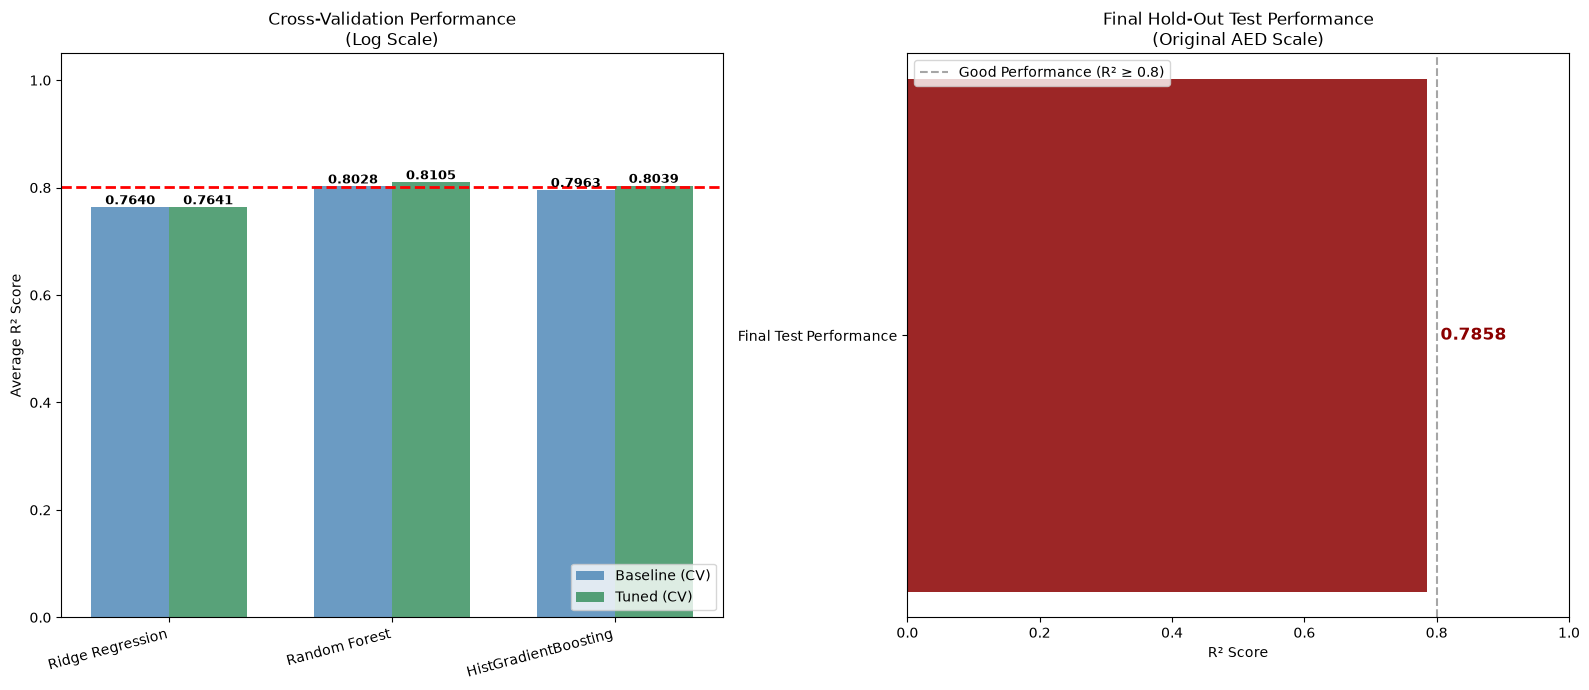

In [85]:
model_names = list(cv_results.keys())
baseline_scores = [cv_results[n] for n in model_names]
tuned_scores_list = [tuned_scores[n] for n in model_names]

x = np.arange(len(model_names))
width = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# ==================== Left Plot: Log Scale (CV Scores) ====================
bars1 = ax1.bar(x - width/2, baseline_scores, width, label='Baseline (CV)', 
                color='steelblue', alpha=0.8)
bars2 = ax1.bar(x + width/2, tuned_scores_list, width, label='Tuned (CV)', 
                color='seagreen', alpha=0.8)

ax1.set_ylabel('Average R² Score')
ax1.set_title('Cross-Validation Performance\n(Log Scale)')
ax1.set_xticks(x)
ax1.set_xticklabels(model_names, rotation=15, ha='right')
ax1.set_ylim(0, 1.05)
ax1.legend(loc='lower right')


# this line shows how the best model actually did on the holdout test set in the original price scale, which is the most important real-world metric
ax1.axhline(y=log_r2, color='red', linestyle='--', linewidth=2, 
           label=f'Final Test R² (Original Scale) = {log_r2:.4f}')

# Value labels
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{bar.get_height():.4f}', ha='center', fontsize=9, fontweight='bold')
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{bar.get_height():.4f}', ha='center', fontsize=9, fontweight='bold')

# ==================== Right Plot: Original AED Scale (Final Test) ====================
# Since we only have one final test score, we show it as a clear reference bar

ax2.barh(['Final Test Performance'], [true_r2], color='darkred', alpha=0.85, height=0.6)

ax2.set_xlabel('R² Score')
ax2.set_title('Final Hold-Out Test Performance\n(Original AED Scale)')
ax2.set_xlim(0, 1.0)

# Add the actual value
ax2.text(true_r2 + 0.02, 0, f'{true_r2:.4f}', 
         va='center', fontsize=12, fontweight='bold', color='darkred')

# Reference line for context
ax2.axvline(x=0.8, color='gray', linestyle='--', alpha=0.7, label='Good Performance (R² ≥ 0.8)')
ax2.legend()

plt.tight_layout()
plt.show()

## 3.5. Model Comparison and Review
### 3.5.1. Plot 1: Actual vs Predicted Prices (X_test)

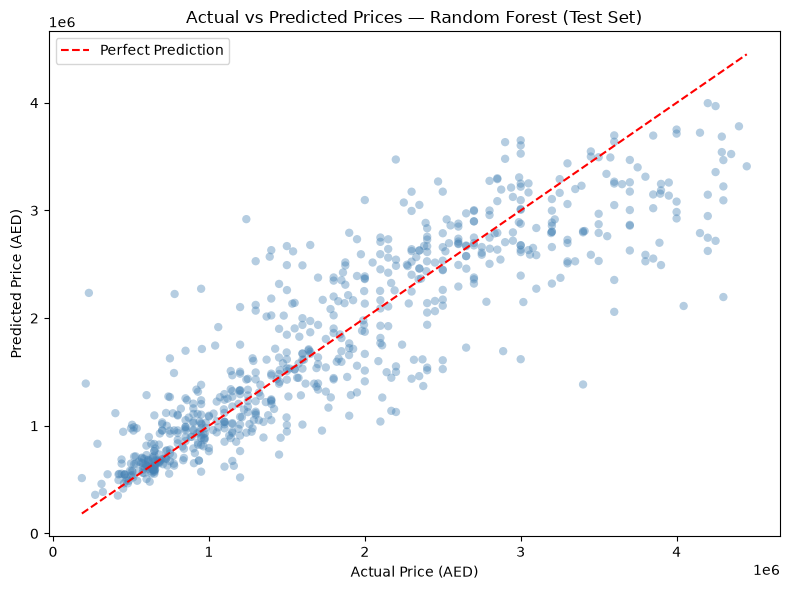

In [86]:
# each dot = one property, x = real price, y = what our model guessed
# the red line = perfect predictions, dots close to it = good predictions
# Use the original AED values for both axes (much more interpretable)
y_test_original = np.expm1(y_test)
final_predictions = np.expm1(final_predictions_log)   # make sure this variable exists

plt.figure(figsize=(8, 6))
plt.scatter(y_test_original, final_predictions, alpha=0.4, color='steelblue', edgecolors='none')

# Perfect prediction line
min_val = min(y_test_original.min(), final_predictions.min())
max_val = max(y_test_original.max(), final_predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], 
         color='red', linewidth=1.5, linestyle='--', label='Perfect Prediction')

plt.xlabel('Actual Price (AED)')
plt.ylabel('Predicted Price (AED)')
plt.title(f'Actual vs Predicted Prices — {best_tuned_name} (Test Set)')
plt.legend()
plt.tight_layout()
plt.show()

### 3.5.2. Plot 2: Residual Plot (X_test)

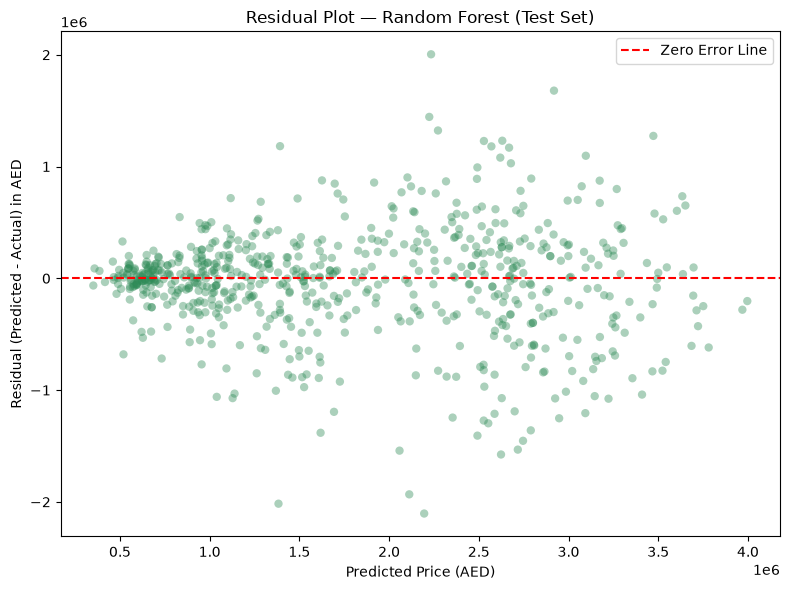

In [87]:
# residual = predicted price minus actual price
# dots scattered randomly around 0 = good, any pattern = the model has a bias problem
# Use consistent original scale for both actual and predicted values
y_test_original   = np.expm1(y_test)
final_predictions = np.expm1(final_predictions_log)   # ensure this is defined

# Calculate residuals in original AED units
residuals = final_predictions - y_test_original

plt.figure(figsize=(8, 6))
plt.scatter(final_predictions, residuals, alpha=0.4, color='seagreen', edgecolors='none')

plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5, label='Zero Error Line')

plt.xlabel('Predicted Price (AED)')
plt.ylabel('Residual (Predicted - Actual) in AED')
plt.title(f'Residual Plot — {best_tuned_name} (Test Set)')
plt.legend()
plt.tight_layout()
plt.show()

### 3.5.3. Plot 3: Feature Importance - Random Forest

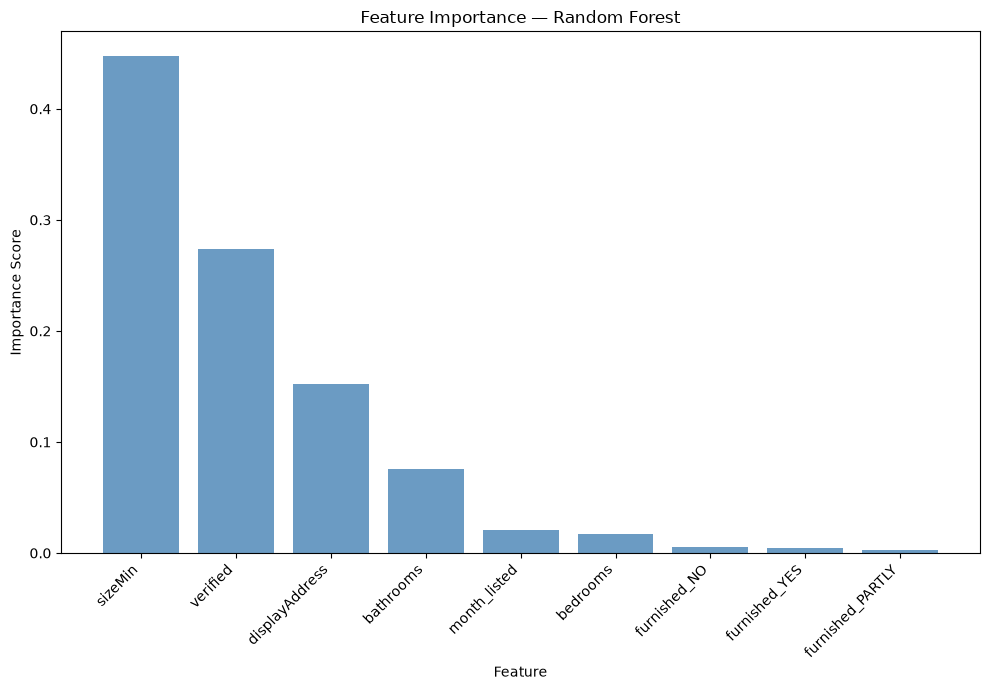


Top 10 Most Important Features (Random Forest):
   1. sizeMin                   : 0.4474
   2. verified                  : 0.2741
   3. displayAddress            : 0.1520
   4. bathrooms                 : 0.0760
   5. month_listed              : 0.0211
   6. bedrooms                  : 0.0171
   7. furnished_NO              : 0.0051
   8. furnished_YES             : 0.0042
   9. furnished_PARTLY          : 0.0030


In [88]:
# shows which features the model used most when deciding the predicted price
# higher bar = that feature had more influence on predictions
# Get the best model from the final pipeline
final_model = best_tuned_estimators[best_tuned_name]
model_step = final_model.named_steps['model']

# Check if the model supports feature importance
if hasattr(model_step, 'feature_importances_'):
    importances = model_step.feature_importances_
    
    # Get feature names after preprocessing (this is tricky with ColumnTransformer)
    # For simplicity, we'll use the original column names where possible
    try:
        # This works reasonably well with our current preprocessor
        feature_names = X_train.columns
    except:
        feature_names = [f"Feature {i}" for i in range(len(importances))]
    
    # Sort features by importance
    sorted_idx = np.argsort(importances)[::-1]
    sorted_importances = importances[sorted_idx]
    sorted_names = [feature_names[i] for i in sorted_idx]
    
    # Plot
    plt.figure(figsize=(10, 7))
    plt.bar(range(len(sorted_importances)), sorted_importances, color='steelblue', alpha=0.8)
    
    plt.xticks(range(len(sorted_names)), sorted_names, rotation=45, ha='right')
    plt.xlabel('Feature')
    plt.ylabel('Importance Score')
    plt.title(f'Feature Importance — {best_tuned_name}')
    plt.tight_layout()
    plt.show()
    
    # Print top 10 features for clarity
    print(f"\nTop 10 Most Important Features ({best_tuned_name}):")
    for i in range(min(10, len(sorted_names))):
        print(f"  {i+1:2d}. {sorted_names[i]:25} : {sorted_importances[i]:.4f}")
        
else:
    print(f"Feature importance plot is not available for {best_tuned_name}.")

### 3.5.4. Plot 4: Cross-Validation Score Distribution (Box Plot)

Running final cross-validation on tuned models...
  Ridge Regression          → Mean R²: 0.7641 (±0.0169)
  Random Forest             → Mean R²: 0.8105 (±0.0203)
  HistGradientBoosting      → Mean R²: 0.8039 (±0.0223)


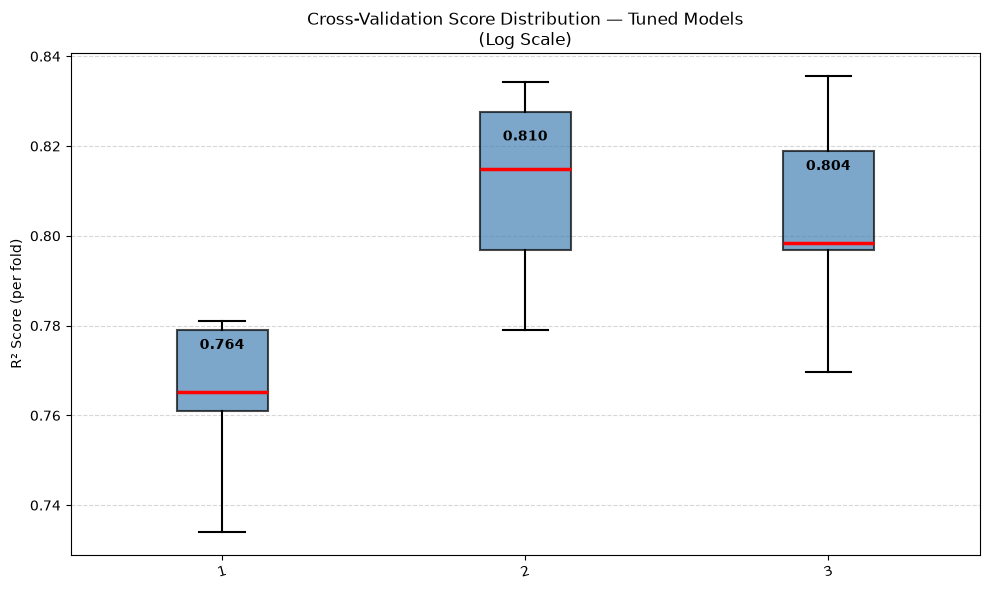

In [ ]:
# Instead of just showing the average R2, this shows the spread across all 5 folds
# A short box sitting high = consistent and accurate performance
# A tall box = unstable / high variance performance

all_cv_scores = {}

print("Running final cross-validation on tuned models...")

for name, model in best_tuned_estimators.items():
    # Re-run CV on the tuned model to get individual fold scores
    scores = cross_val_score(
        model, 
        X_train, 
        y_train, 
        cv=kf, 
        scoring='r2',
        n_jobs=-1
    )
    all_cv_scores[name] = scores
    print(f"  {name:25} -> Mean R2: {np.mean(scores):.4f} (±{np.std(scores):.4f})")


plt.figure(figsize=(10, 6))

plt.boxplot(
    all_cv_scores.values(),
    label=all_cv_scores.keys(),
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.7, linewidth=1.5),
    medianprops=dict(color='red', linewidth=2.5),
    whiskerprops=dict(color='black', linewidth=1.5),
    capprops=dict(color='black', linewidth=1.5)
)

plt.ylabel('R² Score (per fold)')
plt.title('Cross-Validation Score Distribution — Tuned Models\n(Log Scale)')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add mean values as text on the plot
for i, (name, scores) in enumerate(all_cv_scores.items()):
    mean_score = np.mean(scores)
    plt.text(i + 1, mean_score + 0.01, f'{mean_score:.3f}', 
             ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

### 3.5.5. Summary Table: All Models Baseline vs Tuned vs Final Test

In [90]:
# brings all the key numbers together in one place for easy comparison
# final test score only applies to the winning model (Random Forest)

print("=" * 70)
print(f"{'Model':<25} {'Baseline R2 (CV)':>15} {'Tuned R2 (CV)':>15} {'Final Test R2':>15}")
print("=" * 70)

for name in cv_results.keys():
    baseline = cv_results[name]
    tuned    = tuned_scores.get(name, np.nan)
    
    # Only the best model has a final test score on original scale
    if name == best_tuned_name:
        test_str = f"{true_r2:.4f}"
    else:
        test_str = "-"
    
    print(f"{name:<25} {baseline:>15.4f} {tuned:>15.4f} {test_str:>15}")

print("=" * 70)

print(f"\n Final Selected Model : {best_tuned_name}")
print(f" Final Test R² (Original AED) : {true_r2:.4f}")
print(f" Final Test RMSE (Original AED): {true_rmse:,.0f} AED")
print(f" Final Test MAE  (Original AED): {true_mae:,.0f} AED")

Model                     Baseline R2 (CV)   Tuned R2 (CV)   Final Test R2
Ridge Regression                   0.7640          0.7641               -
Random Forest                      0.8028          0.8105          0.7858
HistGradientBoosting               0.7963          0.8039               -

 Final Selected Model : Random Forest
 Final Test R² (Original AED) : 0.7858
 Final Test RMSE (Original AED): 485,761 AED
 Final Test MAE  (Original AED): 339,256 AED
